# Project Part 3

Student 3: NERC Expert (Named Entity Recognition)
Coding Task: * Work exclusively on NER-test.tsv.

Implement an NLP system for NERC that handles the BIO tagging format (you can use SpaCy's NER pipeline, a CRF model, or a token-classification BERT).

Evaluate performance at the token level (B-PER, I-PER, B-ORG, etc.) on the test set and generate a classification report.

Poster Writing Task: * Explain the NERC task, the theoretical background of the BIO format, and your chosen architecture/hyperparameters.

Perform a qualitative error analysis (e.g., point out instances where the system confused an Organization with a Location or Person) and suggest how to improve it.

In [1]:
%pip install spacy scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------- ------------------------------ 2.9/12.8 MB 24.0 MB/s eta 0:00:01
     ---------------------- ----------------- 7.3/12.8 MB 22.7 MB/s eta 0:00:01
     ------------------------------------ -- 12.1/12.8 MB 22.9 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 22.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
# load the English NER model, which we will be using to identify the named entities in the test data

import spacy

nlp = spacy.load("en_core_web_sm")



In [4]:
# test the model on a sentence to make sure the entity recognition is working

doc = nlp("Jane Austen lived in Amsterdam and worked with Warner Brothers.")

for ent in doc.ents:
    print(ent.text, ent.label_)

Jane Austen PERSON
Amsterdam GPE
Warner Brothers ORG


In [5]:
# looad the NER test dataset 

import pandas as pd

df = pd.read_csv("NER-test.tsv", sep="\t")

# display the dimensions and distribution of the labels
print(df.head())
print(df.shape)
print(df["BIO NER tag"].value_counts())

   sentence id  token id  token BIO NER tag
0            0         0     It           O
1            0         1   took           O
2            0         2  eight           O
3            0         3  years           O
4            0         4    for           O
(214, 4)
BIO NER tag
O         183
I-PER       8
B-PER       6
B-ORG       4
B-LOC       4
I-ORG       3
B-MISC      3
I-LOC       2
I-MISC      1
Name: count, dtype: int64


In [6]:
# reconstruct the sentences
sentences = []

for sent_id, group in df.groupby("sentence id"):
    tokens = group["token"].tolist()
    text = " ".join(tokens)

    # store the text, tokens, and gold BIO tags
    sentences.append({
        "sentence_id": sent_id,
        "text": text,
        "tokens": tokens,
        "gold_tags": group["BIO NER tag"].tolist()
    })

print(sentences[0])

{'sentence_id': 0, 'text': 'It took eight years for Warner Brothers to recover from the disaster that was this movie .', 'tokens': ['It', 'took', 'eight', 'years', 'for', 'Warner', 'Brothers', 'to', 'recover', 'from', 'the', 'disaster', 'that', 'was', 'this', 'movie', '.'], 'gold_tags': ['O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [7]:
# map the spacy labels to the entity categories in the dataset

spacy_to_dataset = {
    "PERSON": "PER",
    "ORG": "ORG",
    "GPE": "LOC",
    "LOC": "LOC",
    "FAC": "LOC",
    "NORP": "MISC",
    "EVENT": "MISC",
    "WORK_OF_ART": "MISC",
    "LANGUAGE": "MISC",
    "PRODUCT": "MISC"
}

In [8]:
# generate the BIO predicition by running spacy NER on each sentence in the dataset

all_gold = []
all_pred = []

for sentence in sentences:

    doc = nlp(sentence["text"])

    pred_tags = ["O"] * len(sentence["tokens"])

    for ent in doc.ents:

        label = spacy_to_dataset.get(ent.label_)

        if label is None:
            continue

        start = ent.start
        end = ent.end

        pred_tags[start] = f"B-{label}"

        for i in range(start + 1, end):
            pred_tags[i] = f"I-{label}"

    all_gold.extend(sentence["gold_tags"])
    all_pred.extend(pred_tags)

# track the number of tags in the dataset and the number of tags predicted to make sure we covered everything
print("Gold tags:", len(all_gold))
print("Predicted tags:", len(all_pred))

Gold tags: 214
Predicted tags: 214


In [9]:
# crewarte classification report for precision, recall, and f1-score for each tag

from sklearn.metrics import classification_report

print(
    classification_report(
        all_gold,
        all_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       B-LOC       1.00      1.00      1.00         4
      B-MISC       1.00      1.00      1.00         3
       B-ORG       0.67      0.50      0.57         4
       B-PER       0.57      0.67      0.62         6
       I-LOC       1.00      1.00      1.00         2
      I-MISC       1.00      1.00      1.00         1
       I-ORG       0.75      1.00      0.86         3
       I-PER       1.00      0.75      0.86         8
           O       0.99      0.99      0.99       183

    accuracy                           0.97       214
   macro avg       0.89      0.88      0.88       214
weighted avg       0.97      0.97      0.97       214



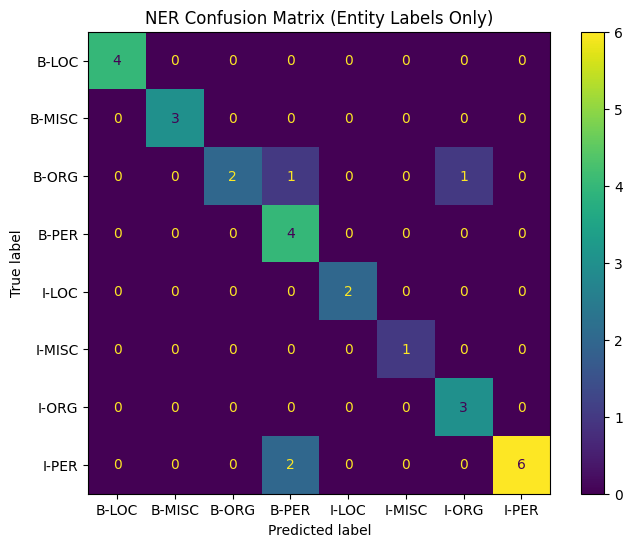

In [11]:
# create confusion matrix to show the way the labels are classified by the model

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

labels = [x for x in sorted(set(all_gold) | set(all_pred)) if x != "O"]

cm = confusion_matrix(
    all_gold,
    all_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax)

plt.title("NER Confusion Matrix (Entity Labels Only)")
plt.show()

In [12]:
# examples where predicted label was wrong

for i in range(len(all_gold)):
    if all_gold[i] != all_pred[i]:
        print(
            f"Gold: {all_gold[i]:10} Pred: {all_pred[i]:10}"
        )

Gold: O          Pred: B-ORG     
Gold: B-ORG      Pred: I-ORG     
Gold: B-ORG      Pred: B-PER     
Gold: B-PER      Pred: O         
Gold: I-PER      Pred: B-PER     
Gold: B-PER      Pred: O         
Gold: I-PER      Pred: B-PER     


In [15]:
# output of the wrong token analysis including the Gold and Predicted tags
for sentence in sentences:

    doc = nlp(sentence["text"])

    pred_tags = ["O"] * len(sentence["tokens"])

    for ent in doc.ents:

        label = spacy_to_dataset.get(ent.label_)

        if label is None:
            continue

        pred_tags[ent.start] = f"B-{label}"

        for i in range(ent.start + 1, ent.end):
            pred_tags[i] = f"I-{label}"

    for token, gold, pred in zip(
        sentence["tokens"],
        sentence["gold_tags"],
        pred_tags
    ):
        if gold != pred:
            print(
                f"Token: {token:15} Gold: {gold:10} Pred: {pred:10}"
            )

Token: the             Gold: O          Pred: B-ORG     
Token: New             Gold: B-ORG      Pred: I-ORG     
Token: Blauwbrug       Gold: B-ORG      Pred: B-PER     
Token: Dame            Gold: B-PER      Pred: O         
Token: Maggie          Gold: I-PER      Pred: B-PER     
Token: Mr.             Gold: B-PER      Pred: O         
Token: Kruno           Gold: I-PER      Pred: B-PER     


In [17]:
# output of the wrong token analysis including the Gold and Predicted tags including the sentence of the given tokens

for sentence in sentences:

    doc = nlp(sentence["text"])

    pred_tags = ["O"] * len(sentence["tokens"])

    for ent in doc.ents:

        label = spacy_to_dataset.get(ent.label_)

        if label is None:
            continue

        pred_tags[ent.start] = f"B-{label}"

        for i in range(ent.start + 1, ent.end):
            pred_tags[i] = f"I-{label}"

    if sentence["gold_tags"] != pred_tags:

        print("\nSentence:")
        print(sentence["text"])

        for token, gold, pred in zip(
            sentence["tokens"],
            sentence["gold_tags"],
            pred_tags
        ):
            if gold != pred:
                print(
                    f"{token:15} Gold={gold:10} Pred={pred}"
                )


Sentence:
All the New York University students love this diner in Soho so it makes for a fun young atmosphere .
the             Gold=O          Pred=B-ORG
New             Gold=B-ORG      Pred=I-ORG

Sentence:
My husband and I moved to Amsterdam 6 years ago and for as long as we have lived here , Blauwbrug has been our favorite place to eat !
Blauwbrug       Gold=B-ORG      Pred=B-PER

Sentence:
Dame Maggie Smith performed her role excellently , as she does in all her movies .
Dame            Gold=B-PER      Pred=O
Maggie          Gold=I-PER      Pred=B-PER

Sentence:
The new movie by Mr. Kruno was shot in New York , but the story takes place in Los Angeles .
Mr.             Gold=B-PER      Pred=O
Kruno           Gold=I-PER      Pred=B-PER


# Errors

#### __Error 1: Organization boundary error__

-- Sentence:

- All the New York University students love this diner in Soho so it makes for a fun young atmosphere .

-- Gold:

- New  -> B-ORG
- York -> I-ORG
- University -> I-ORG

-- Prediction:

- the  -> B-ORG
- New  -> I-ORG
- York -> I-ORG
- University -> I-ORG


-- Explanation:

- The model correctly identified the university as an organization but incorrectly extended the entity boundary to include the preceding word "the". This demonstrates a common NER boundary detection error where surrounding context is mistakenly incorporated into the entity span.


#### __Error 2: Entity type confusion__

-- Sentence:

- ...Blauwbrug has been our favorite place to eat 

-- Gold:

- Blauwbrug -> B-ORG

-- Prediction:

- Blauwbrug -> B-PER

-- Explanation:

- The model confused an organization entity with a person entity. This likely occurred because "Blauwbrug" is an uncommon proper noun and the pretrained model lacked sufficient context to determine its correct category.

#### __Error 3: Person boundary confusion__

-- Sentence:

- TDame Maggie Smith performed her role excellently , as she does in all her movies .

-- Gold:

- Dame   -> B-PER
- Maggie -> I-PER
- Smith  -> I-PER

-- Prediction:

- Dame   -> O
- Maggie -> B-PER
- Smith  -> I-PER

-- Explanation:

- The model recognized the person entity but failed to identify the honorific "Dame" as part of the name. Instead, it started the entity at "Maggie", producing an incorrect BIO boundary. This suggests difficulty handling titles that precede personal names.


#### __Error 4: Person boundary confusion__

-- Sentence:

- The new movie by Mr. Kruno was shot in New York , but the story takes place in Los Angeles .

-- Gold:

- Mr.   -> B-PER
- Kruno -> I-PER

-- Prediction:

- Mr.   -> O
- Kruno -> B-PER

-- Explanation:

- Similar to the previous example, the model failed to include the title "Mr." within the person entity and instead began the entity at the following token. The entity type was identified correctly, but the BIO boundary was predicted incorrectly.




# Datasaet:

We performed the evaluation on the provided NER-test.tsv dataset. The dataset contains 214 tokens annotated using the BIO tagging scheme. Four entity categories are present: Person (PER), Organization (ORG), Location (LOC), and Miscellaneous (MISC). The dataset was supplied to us as part of the course evaluation materials and was used as the gold-standard reference for performance evaluation.

# Methodology:

We used the pretrained SpaCy English NER model (en_core_web_sm) and evaluated its performance on the provided NER test set. The model identifies named entities such as persons, organizations, locations, and miscellaneous entities within text. We mapped Spacy enitity labels to the dataset labels (PER, ORG, LOC, MISC) and converted into BIO tags before evaluation. We converted the predictions generated by the model into BIO tags to match the annotation format of the evaluation dataset. We evaluated the performance at the token level using Precision, Recall, F1-score, and a confusion matrix. No additional model training was performedm since we applied a pretrained NER model to the test dataset and evaluated against the gold-standard annotations.

# BIO Explanation:

The BIO tagging scheme is commonly used for Named Entity Recognition. B (Beginning) marks the first token of an entity, I (Inside) marks subsequent tokens belonging to the same entity, and O (Outside) indicates that a token does not belong to any named entity. For example, in the phrase "Jane Austen", the token "Jane" receives the tag B-PER and "Austen" receives I-PER, indicating that both tokens belong to the same person entity.

# Results:

The SpaCy NER system achieved an overall accuracy of 97% and a weighted F1-score of 0.97 on the NER test set. Most entity categories were identified correctly, including locations, organizations, and miscallenaous entities. The primary errors involved incorrect entity boundaries and confusion between B and I tags. Despite these errors, the model demonstrated strong performance without task-specific training, which shows the effectiveness of modern pretrained NER systems.




# Limitations:

- We had a small evaluation set with only 214 tokens
- We used a pretrained model that is not fine-tuned on the dataset provided
- We had errors on multi-word entities
- The model occassionally confuses B and I BIO tags

# Improvements 

- We should fine-tune a transformer model
- We could train a CRF or BERT NER system
- We should use a much larger training dataset